# 04 - Model Comparison

## Part 1: Close-price distribution and candidate outlier boundaries

Before comparing Week 5 models, inspect the training-target distribution and quantify possible outlier cutoffs. Cutoffs are learned from the **training set only** so validation remains useful for model selection and May 2026 remains untouched.

This section reports candidate boundaries but does not remove any observations automatically.

In [24]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd
import seaborn as sns

In [25]:
DATA_FILE = Path("data/week5_unstandardized_model_data.csv")
CUTOFF_RESULTS_FILE = Path("data/week5_price_cutoff_candidates.csv")
HISTOGRAM_FILE = Path("data/week5_price_distribution_histograms.png")

TRAIN_MONTHS = pd.period_range("2025-02", "2026-01", freq="M").astype(str).tolist()
VALIDATION_MONTHS = pd.period_range("2026-02", "2026-04", freq="M").astype(str).tolist()
TEST_MONTHS = ["2026-05"]

df = pd.read_csv(DATA_FILE, low_memory=False)
train = df[df["split"] == "train"].copy()
validation = df[df["split"] == "validation"].copy()
test = df[df["split"] == "test"].copy()

expected_months = {
    "train": TRAIN_MONTHS,
    "validation": VALIDATION_MONTHS,
    "test": TEST_MONTHS,
}
for split_name, months in expected_months.items():
    actual = sorted(df.loc[df["split"] == split_name, "close_month"].unique())
    assert actual == months, (split_name, actual, months)

print(f"Training rows used for cutoff analysis: {len(train):,}")
print("Validation and test prices are not used to calculate cutoffs.")

Training rows used for cutoff analysis: 129,443
Validation and test prices are not used to calculate cutoffs.


## Training-price summary

In [26]:
price = train["ClosePrice"].dropna()
log_price = np.log1p(price)

summary = pd.Series({
    "rows": len(price),
    "minimum": price.min(),
    "mean": price.mean(),
    "median": price.median(),
    "maximum": price.max(),
    "standard_deviation": price.std(),
    "raw_price_skew": price.skew(),
    "log_price_skew": log_price.skew(),
})
summary.to_frame("value")

,value
rows,1.294430e+05
minimum,1.300000e+04
mean,1.234853e+06
median,8.875000e+05
maximum,2.000000e+07
standard_deviation,1.213023e+06
raw_price_skew,5.159049e+00
log_price_skew,4.631656e-01


## Histograms

The full-range histogram shows the luxury tail. The middle plot expands the main 99% of observations. The log-price histogram shows the distribution without allowing a small number of expensive homes to compress the rest of the chart.

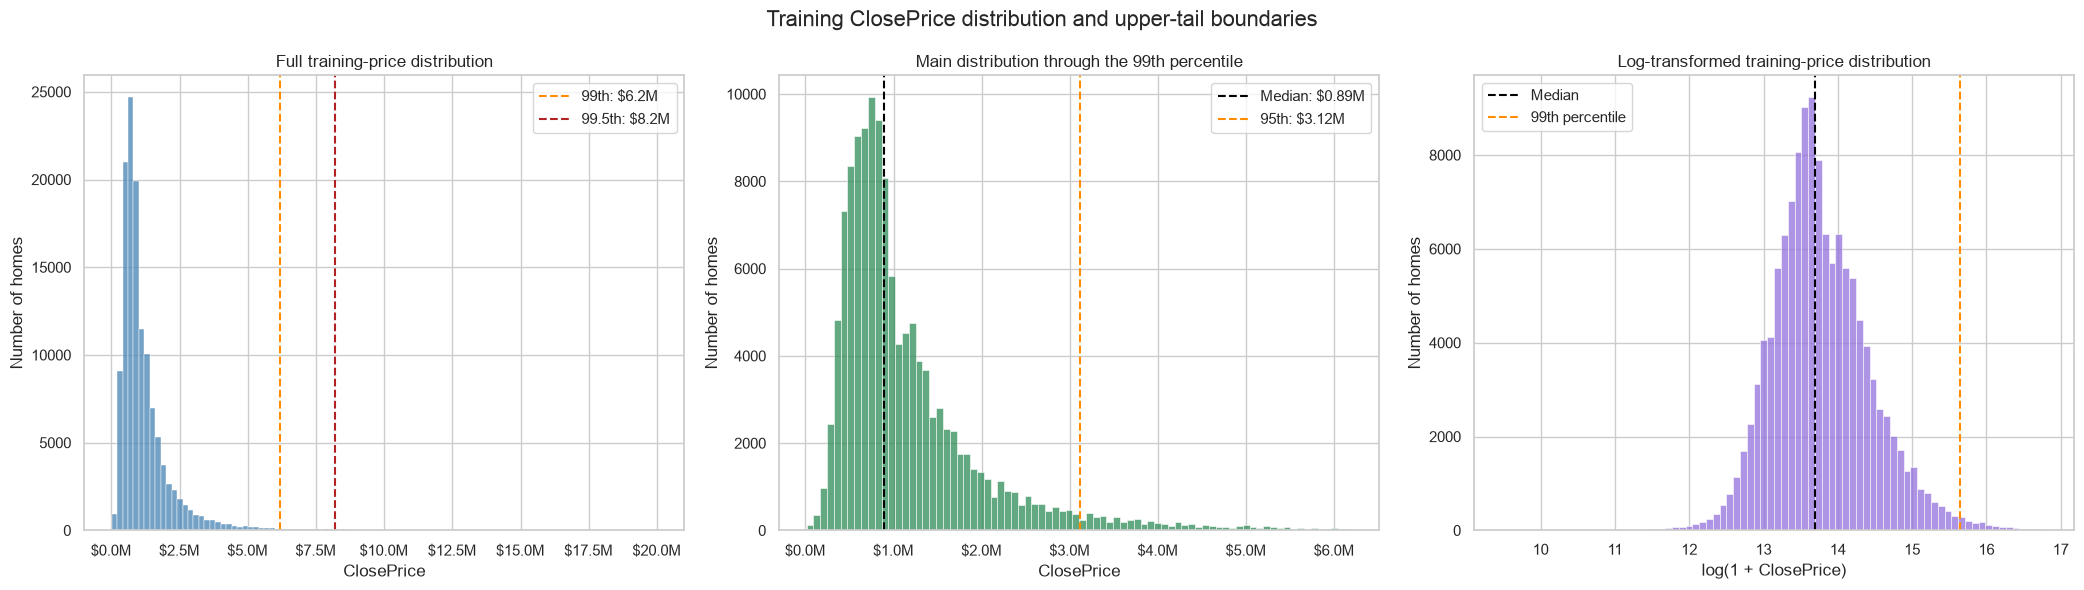

Saved data/week5_price_distribution_histograms.png


In [27]:
def millions(value, _):
    return f"${value / 1_000_000:.1f}M"

p50 = price.quantile(0.50)
p95 = price.quantile(0.95)
p99 = price.quantile(0.99)
p995 = price.quantile(0.995)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

sns.histplot(price, bins=100, color="steelblue", ax=axes[0])
axes[0].axvline(p99, color="darkorange", linestyle="--", label=f"99th: ${p99/1e6:.1f}M")
axes[0].axvline(p995, color="firebrick", linestyle="--", label=f"99.5th: ${p995/1e6:.1f}M")
axes[0].set_title("Full training-price distribution")
axes[0].set_xlabel("ClosePrice")
axes[0].xaxis.set_major_formatter(FuncFormatter(millions))
axes[0].legend()

central_price = price[price <= p99]
sns.histplot(central_price, bins=80, color="seagreen", ax=axes[1])
axes[1].axvline(p50, color="black", linestyle="--", label=f"Median: ${p50/1e6:.2f}M")
axes[1].axvline(p95, color="darkorange", linestyle="--", label=f"95th: ${p95/1e6:.2f}M")
axes[1].set_title("Main distribution through the 99th percentile")
axes[1].set_xlabel("ClosePrice")
axes[1].xaxis.set_major_formatter(FuncFormatter(millions))
axes[1].legend()

sns.histplot(log_price, bins=80, color="mediumpurple", ax=axes[2])
axes[2].axvline(np.log1p(p50), color="black", linestyle="--", label="Median")
axes[2].axvline(np.log1p(p99), color="darkorange", linestyle="--", label="99th percentile")
axes[2].set_title("Log-transformed training-price distribution")
axes[2].set_xlabel("log(1 + ClosePrice)")
axes[2].legend()

for ax in axes:
    ax.set_ylabel("Number of homes")

fig.suptitle("Training ClosePrice distribution and upper-tail boundaries", fontsize=16)
fig.tight_layout()
fig.savefig(HISTOGRAM_FILE, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved {HISTOGRAM_FILE}")

## Candidate lower and upper cutoffs

Percentile cutoffs are more useful than a conventional IQR fence for this market because high-priced homes form a real luxury segment. The IQR rule is included as a reference, not as an automatic recommendation.

In [28]:
q1 = price.quantile(0.25)
q3 = price.quantile(0.75)
iqr = q3 - q1
iqr_lower = q1 - 1.5 * iqr
iqr_upper = q3 + 1.5 * iqr

candidate_definitions = [
    ("existing hard floor", "lower", 10_000.0, "Existing preprocessing rule"),
    ("0.1st percentile", "lower", price.quantile(0.001), "Very conservative review boundary"),
    ("0.5th percentile", "lower", price.quantile(0.005), "Removes 0.5% of the low tail"),
    ("1st percentile", "lower", price.quantile(0.01), "Removes 1% of the low tail"),
    ("IQR upper fence", "upper", iqr_upper, "Conventional rule; aggressive for luxury housing"),
    ("99th percentile", "upper", price.quantile(0.99), "Removes about 1% of the high tail"),
    ("99.5th percentile", "upper", price.quantile(0.995), "Removes about 0.5% of the high tail"),
    ("99.9th percentile", "upper", price.quantile(0.999), "Very conservative high-tail boundary"),
    ("existing hard ceiling", "upper", 20_000_000.0, "Existing preprocessing rule"),
]

cutoff_rows = []
for name, side, cutoff, note in candidate_definitions:
    affected = int((price < cutoff).sum()) if side == "lower" else int((price > cutoff).sum())
    cutoff_rows.append({
        "candidate": name,
        "side": side,
        "cutoff_price": cutoff,
        "training_rows_beyond_cutoff": affected,
        "training_pct_beyond_cutoff": affected / len(price) * 100,
        "note": note,
    })

cutoff_table = pd.DataFrame(cutoff_rows)
cutoff_table.to_csv(CUTOFF_RESULTS_FILE, index=False)
cutoff_display = cutoff_table.copy()
cutoff_display["cutoff_price"] = cutoff_display["cutoff_price"].map(lambda value: f"${value:,.0f}")
cutoff_display["training_pct_beyond_cutoff"] = cutoff_display["training_pct_beyond_cutoff"].round(3)
cutoff_display

,candidate,side,cutoff_price,training_rows_beyond_cutoff,training_pct_beyond_cutoff,note
0,existing hard floor,lower,"$10,000",0,0.000,Existing preprocessing rule
1,0.1st percentile,lower,"$91,000",129,0.100,Very conservative review boundary
2,0.5th percentile,lower,"$189,000",647,0.500,Removes 0.5% of the low tail
3,1st percentile,lower,"$238,510",1295,1.000,Removes 1% of the low tail
4,IQR upper fence,upper,"$2,587,500",9872,7.627,Conventional rule; aggressive for luxury housing
5,99th percentile,upper,"$6,200,000",1288,0.995,Removes about 1% of the high tail
6,99.5th percentile,upper,"$8,200,000",646,0.499,Removes about 0.5% of the high tail
7,99.9th percentile,upper,"$13,750,000",128,0.099,Very conservative high-tail boundary
8,existing hard ceiling,upper,"$20,000,000",0,0.000,Existing preprocessing rule


## Interpretation and decision boundary

- The distribution is strongly right-skewed on the dollar scale but much closer to symmetric after `log1p`.
- The IQR upper fence is approximately **$2.59M** and would remove about **7.6%** of training homes. That is too aggressive to call those rows data errors automatically.
- The **99th percentile is approximately $6.20M**, the **99.5th percentile is approximately $8.20M**, and the **99.9th percentile is approximately $13.75M**.
- The selected upper boundary is the **training 99.5th percentile ($8.20M)**. This removes the highest 0.5% of training prices.
- On the lower side, prices below the **0.1st percentile (about $91K)** require a targeted data-quality review because the group contains both legitimate low-cost rural homes and apparent price-entry errors.

## Bottom-tail audit

A low percentile alone is not enough reason to delete a transaction. Compare `ClosePrice` with `ListPrice` to distinguish plausible inexpensive homes from likely missing-zero or misplaced-decimal errors. This audit uses training rows only.

In [29]:
LOW_REVIEW_BOUNDARY = price.quantile(0.001)
BOTTOM_AUDIT_FILE = Path("data/week5_bottom_tail_audit.csv")

bottom_tail = train[train["ClosePrice"] < LOW_REVIEW_BOUNDARY].copy()
bottom_tail["sale_to_list_ratio"] = (
    bottom_tail["ClosePrice"] / bottom_tail["ListPrice"].replace(0, np.nan)
)

bottom_summary = pd.Series({
    "review_boundary": LOW_REVIEW_BOUNDARY,
    "rows_below_boundary": len(bottom_tail),
    "rows_below_50_pct_of_list": int((bottom_tail["sale_to_list_ratio"] < 0.50).sum()),
    "rows_below_10_pct_of_list": int((bottom_tail["sale_to_list_ratio"] < 0.10).sum()),
    "median_sale_to_list_ratio": bottom_tail["sale_to_list_ratio"].median(),
    "median_living_area": bottom_tail["LivingArea"].median(),
})
bottom_tail.to_csv(BOTTOM_AUDIT_FILE, index=False)
bottom_summary.to_frame("value")

,value
review_boundary,91000.000000
rows_below_boundary,129.000000
rows_below_50_pct_of_list,40.000000
rows_below_10_pct_of_list,17.000000
median_sale_to_list_ratio,0.857143
median_living_area,1084.000000


In [30]:
bottom_columns = [
    "ListingId", "CloseDate", "ClosePrice", "ListPrice",
    "sale_to_list_ratio", "LivingArea", "BedroomsTotal",
    "BathroomsTotalInteger", "YearBuilt", "City", "PostalCode",
]
bottom_tail.nsmallest(30, "ClosePrice")[bottom_columns]

,ListingId,CloseDate,ClosePrice,ListPrice,sale_to_list_ratio,LivingArea,BedroomsTotal,BathroomsTotalInteger,YearBuilt,City,PostalCode
59383,219132672DA,2025-07-13,13000.0,13000.0,1.000000,192.0,0.0,0.0,1957.0,29 Palms,92277
66607,IG25124853,2025-07-31,15000.0,434800.0,0.034499,896.0,2.0,1.0,1961.0,Menifee,92587
23590,SR25035806,2025-04-10,16000.0,1599000.0,0.010006,2088.0,4.0,3.0,1950.0,Woodland Hills,91364
23626,TR24247403,2025-04-10,18380.0,1849000.0,0.009941,3352.0,5.0,5.0,1998.0,Rowland Heights,91748
14631,SN24186466,2025-03-18,25000.0,25000.0,1.000000,883.0,3.0,1.0,1948.0,Oroville,95966
14961,OC24228609,2025-03-19,26000.0,679000.0,0.038292,1506.0,4.0,2.0,1979.0,Palm Desert,92260
62018,PW25121927,2025-07-18,26000.0,25000.0,1.040000,1500.0,2.0,1.0,1930.0,Red Mountain,93555
67112,IG25057477,2025-08-01,28450.0,35000.0,0.812857,1000.0,1.0,1.0,1930.0,Angelus Oaks,92305
108573,HD25173843,2025-11-20,29000.0,29000.0,1.000000,960.0,3.0,1.0,1950.0,Yermo,92398
110871,250044035SD,2025-11-26,29900.0,29900.0,1.000000,1198.0,1.0,1.0,1953.0,Buttonwillow,93206


### Bottom-tail finding

There are **129** training sales below approximately **$91K**. Many appear plausible and are concentrated in lower-cost markets such as 29 Palms, Needles, Barstow, Trona, and Big River. However, **40** sold below 50% of list price and **17** sold below 10% of list price. Several are almost exact factor-of-10 or factor-of-100 differences—for example, a $16K close against a $1.599M list—suggesting missing-zero data-entry errors.

Therefore, do not remove the bottom 0.1% wholesale. Keep the plausible low-cost homes and revisit the extreme sale-to-list mismatches with a targeted cleaning rule.

## Apply the selected upper cutoff

The $8.20M boundary is calculated from training prices and then applied unchanged to train, validation, and test. This defines one consistent modeling population without calculating separate cutoffs from validation or test targets.

In [31]:
SELECTED_UPPER_CUTOFF = price.quantile(0.995)
FILTERED_DATA_FILE = Path("data/week5_model_data_trimmed_upper_p995.csv")

removal_summary = (
    df.assign(remove_upper_outlier=df["ClosePrice"] > SELECTED_UPPER_CUTOFF)
    .groupby("split", sort=False)
    .agg(
        original_rows=("ClosePrice", "size"),
        rows_removed=("remove_upper_outlier", "sum"),
    )
)
removal_summary["pct_removed"] = (
    removal_summary["rows_removed"] / removal_summary["original_rows"] * 100
)
removal_summary["remaining_rows"] = (
    removal_summary["original_rows"] - removal_summary["rows_removed"]
)

filtered_df = df[df["ClosePrice"] <= SELECTED_UPPER_CUTOFF].copy()
filtered_df.to_csv(FILTERED_DATA_FILE, index=False)

assert filtered_df["ClosePrice"].max() <= SELECTED_UPPER_CUTOFF
assert abs(removal_summary.loc["train", "pct_removed"] - 0.5) < 0.01

print(f"Selected upper cutoff: ${SELECTED_UPPER_CUTOFF:,.0f}")
print(f"Wrote {FILTERED_DATA_FILE} with {len(filtered_df):,} rows")
removal_summary.round({"pct_removed": 3})

Selected upper cutoff: $8,200,000
Wrote data/week5_model_data_trimmed_upper_p995.csv with 172,310 rows


,original_rows,rows_removed,pct_removed,remaining_rows
split,,,,
train,129443,646,0.499,128797
validation,31722,168,0.530,31554
test,12013,54,0.450,11959


# Part 2: Baseline model comparison

Every model is compared under two population policies:

1. **All prices:** retain the complete modeling population.
2. **Trimmed p99.5:** apply the training-derived $8.20M ceiling unchanged to train, validation, and test.

Every model uses one AVM-safe feature set containing structural, amenity, and location information. `ListPrice`, `OriginalListPrice`, and `DaysOnMarket` are explicitly excluded because they are unavailable for off-market properties and leak information from the listing process.

Validation R² selects one configuration. The May 2026 test set is scored only after selection. These are broad baselines, not tuned models.

In [32]:
import gc
import time
import warnings

import joblib
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)
RANDOM_STATE = 42

## AVM feature set and preprocessing

Linear and Ridge regression use one-hot location variables so each location can receive its own coefficient. The tree baselines use training-fitted ordinal category codes for a common, compact matrix. CatBoost receives the original category strings and handles them natively.

In [33]:
property_numeric = [
    "Latitude", "Longitude", "LivingArea", "BuildingAreaTotal",
    "BedroomsTotal", "BathroomsTotalInteger", "HomeAge", "Stories",
    "GarageSpaces", "ParkingTotal", "AssociationFee",
    "LotSizeSquareFeet", "LotSizeAcres", "MainLevelBedrooms",
]
boolean_features = [
    "ViewYN", "WaterfrontYN", "PoolPrivateYN", "AttachedGarageYN",
    "FireplaceYN", "NewConstructionYN",
]
categorical_features = [
    "City", "PostalCode", "CountyOrParish", "MLSAreaMajor",
    "HighSchoolDistrict", "Levels",
]

FEATURE_SETS = {
    "avm_features": {
        "numeric": property_numeric,
        "boolean": boolean_features,
        "categorical": categorical_features,
    },
}
EXCLUDED_AVM_FEATURES = {"ListPrice", "OriginalListPrice", "DaysOnMarket"}
assert EXCLUDED_AVM_FEATURES.isdisjoint(
    set(property_numeric + boolean_features + categorical_features)
)

POPULATIONS = {
    "all_prices": None,
    "trimmed_p995": SELECTED_UPPER_CUTOFF,
}

def make_preprocessor(feature_spec, linear_model):
    numeric_steps = [
        ("imputer", SimpleImputer(strategy="median", keep_empty_features=True)),
    ]
    if linear_model:
        numeric_steps.append(("scaler", StandardScaler()))

    category_encoder = (
        OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=10)
        if linear_model
        else OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1,
            encoded_missing_value=-1,
        )
    )

    return ColumnTransformer([
        ("numeric", Pipeline(numeric_steps), feature_spec["numeric"]),
        ("boolean", "passthrough", feature_spec["boolean"]),
        ("categorical", category_encoder, feature_spec["categorical"]),
    ])

def feature_columns(feature_spec):
    return feature_spec["numeric"] + feature_spec["boolean"] + feature_spec["categorical"]

pd.DataFrame({
    name: {group: len(columns) for group, columns in spec.items()}
    for name, spec in FEATURE_SETS.items()
}).T

,numeric,boolean,categorical
avm_features,14,6,6


## Baseline model definitions

In [34]:
def make_model(model_name):
    if model_name == "LinearRegression":
        return LinearRegression(n_jobs=-1)
    if model_name == "Ridge":
        return Ridge(alpha=10.0)
    if model_name == "HistGradientBoosting":
        return HistGradientBoostingRegressor(
            max_iter=250, learning_rate=0.08, max_leaf_nodes=63,
            l2_regularization=0.1, random_state=RANDOM_STATE,
        )
    if model_name == "RandomForest":
        return RandomForestRegressor(
            n_estimators=180, max_depth=24, min_samples_leaf=2,
            max_features=0.75, n_jobs=-1, random_state=RANDOM_STATE,
        )
    if model_name == "XGBoost":
        return XGBRegressor(
            n_estimators=350, max_depth=8, learning_rate=0.05,
            subsample=0.85, colsample_bytree=0.85, reg_lambda=1.0,
            objective="reg:squarederror", tree_method="hist",
            n_jobs=-1, random_state=RANDOM_STATE, verbosity=0,
        )
    if model_name == "LightGBM":
        return LGBMRegressor(
            n_estimators=400, learning_rate=0.05, num_leaves=63,
            subsample=0.85, subsample_freq=1, colsample_bytree=0.85,
            reg_lambda=1.0, n_jobs=-1, random_state=RANDOM_STATE,
            verbosity=-1,
        )
    raise ValueError(f"Unknown model: {model_name}")

MODEL_NAMES = [
    "LinearRegression", "Ridge", "HistGradientBoosting",
    "RandomForest", "XGBoost", "LightGBM", "CatBoost",
]

## Training helpers

All imputers and encoders are fitted on training rows only. The artifact for the current best validation configuration is retained for the final test evaluation.

In [35]:
def regression_metrics(actual, predicted):
    return {
        "r2": r2_score(actual, predicted),
        "mae": mean_absolute_error(actual, predicted),
        "rmse": float(np.sqrt(mean_squared_error(actual, predicted))),
    }

def prepare_catboost_frames(train_df, other_df, feature_spec):
    columns = feature_columns(feature_spec)
    train_x = train_df[columns].copy()
    other_x = other_df[columns].copy()
    medians = train_x[feature_spec["numeric"]].median()

    train_x[feature_spec["numeric"]] = train_x[feature_spec["numeric"]].fillna(medians)
    other_x[feature_spec["numeric"]] = other_x[feature_spec["numeric"]].fillna(medians)
    for col in feature_spec["categorical"]:
        train_x[col] = train_x[col].fillna("Unknown").astype(str)
        other_x[col] = other_x[col].fillna("Unknown").astype(str)

    return train_x, other_x, medians

def fit_configuration(model_name, feature_spec, train_df, validation_df):
    if model_name == "CatBoost":
        train_x, validation_x, medians = prepare_catboost_frames(
            train_df, validation_df, feature_spec
        )
        model = CatBoostRegressor(
            iterations=400, depth=8, learning_rate=0.08,
            loss_function="RMSE", random_seed=RANDOM_STATE,
            verbose=False, allow_writing_files=False, thread_count=-1,
        )
        model.fit(
            train_x, train_df["ClosePrice"],
            cat_features=feature_spec["categorical"],
        )
        artifact = {
            "kind": "catboost", "model": model, "medians": medians,
            "feature_spec": feature_spec,
        }
        return artifact, model.predict(train_x), model.predict(validation_x)

    linear_model = model_name in {"LinearRegression", "Ridge"}
    pipeline = Pipeline([
        ("preprocessor", make_preprocessor(feature_spec, linear_model)),
        ("model", make_model(model_name)),
    ])
    pipeline.fit(train_df, train_df["ClosePrice"])
    artifact = {"kind": "pipeline", "model": pipeline, "feature_spec": feature_spec}
    return artifact, pipeline.predict(train_df), pipeline.predict(validation_df)

def predict_artifact(artifact, frame):
    if artifact["kind"] == "pipeline":
        return artifact["model"].predict(frame)

    spec = artifact["feature_spec"]
    x = frame[feature_columns(spec)].copy()
    x[spec["numeric"]] = x[spec["numeric"]].fillna(artifact["medians"])
    for col in spec["categorical"]:
        x[col] = x[col].fillna("Unknown").astype(str)
    return artifact["model"].predict(x)

## Run all baseline comparisons

This runs 14 configurations: seven model families × two outlier policies.

In [36]:
COMPARISON_FILE = Path("data/week5_model_comparison_validation_results.csv")
BASELINE_TABLE_FILE = Path("data/week5_baseline_comparison_table.csv")
BEST_MODEL_FILE = Path("data/week5_best_model.joblib")

comparison_rows = []
best_validation_r2 = -np.inf
best_artifact = None
best_configuration = None

for population_name, upper_cutoff in POPULATIONS.items():
    population_train = train if upper_cutoff is None else train[train["ClosePrice"] <= upper_cutoff]
    population_validation = (
        validation if upper_cutoff is None
        else validation[validation["ClosePrice"] <= upper_cutoff]
    )

    for feature_set_name, feature_spec in FEATURE_SETS.items():
        for model_name in MODEL_NAMES:
            started = time.perf_counter()
            artifact, train_pred, validation_pred = fit_configuration(
                model_name, feature_spec, population_train, population_validation
            )
            elapsed = time.perf_counter() - started
            train_metrics = regression_metrics(population_train["ClosePrice"], train_pred)
            validation_metrics = regression_metrics(
                population_validation["ClosePrice"], validation_pred
            )

            row = {
                "population": population_name,
                "upper_cutoff": upper_cutoff,
                "feature_set": feature_set_name,
                "model": model_name,
                "train_rows": len(population_train),
                "validation_rows": len(population_validation),
                "validation_coverage_pct": len(population_validation) / len(validation) * 100,
                "train_r2": train_metrics["r2"],
                "validation_r2": validation_metrics["r2"],
                "validation_mae": validation_metrics["mae"],
                "validation_rmse": validation_metrics["rmse"],
                "fit_seconds": elapsed,
            }
            comparison_rows.append(row)
            print(
                f"{population_name:13s} | {feature_set_name:15s} | {model_name:20s} "
                f"| val R²={validation_metrics['r2']:.4f} | {elapsed:.1f}s"
            )

            if validation_metrics["r2"] > best_validation_r2:
                best_validation_r2 = validation_metrics["r2"]
                best_artifact = artifact
                best_configuration = row.copy()
            else:
                del artifact
            gc.collect()

comparison_results = pd.DataFrame(comparison_rows).sort_values(
    "validation_r2", ascending=False
).reset_index(drop=True)
comparison_results.to_csv(COMPARISON_FILE, index=False)
joblib.dump({"artifact": best_artifact, "configuration": best_configuration}, BEST_MODEL_FILE)

baseline_comparison_table = (
    comparison_results.pivot(
        index="model", columns="population",
        values=["validation_r2", "validation_mae"],
    )
    .rename(columns={
        "validation_r2": "r2",
        "validation_mae": "mae",
    }, level=0)
)
baseline_comparison_table.columns = [
    f"{metric}_{population}" for metric, population in baseline_comparison_table.columns
]
baseline_comparison_table = baseline_comparison_table[[
    "r2_all_prices", "r2_trimmed_p995",
    "mae_all_prices", "mae_trimmed_p995",
]].sort_values("r2_trimmed_p995", ascending=False)
baseline_comparison_table.to_csv(BASELINE_TABLE_FILE)

baseline_display = baseline_comparison_table.copy()
for col in ["r2_all_prices", "r2_trimmed_p995"]:
    baseline_display[col] = baseline_display[col].map(lambda value: f"{value:.4f}")
for col in ["mae_all_prices", "mae_trimmed_p995"]:
    baseline_display[col] = baseline_display[col].map(lambda value: f"${value:,.0f}")

print(f"\nWrote {COMPARISON_FILE}")
print(f"Wrote {BASELINE_TABLE_FILE}")
print(f"Saved selected model to {BEST_MODEL_FILE}")
baseline_display

all_prices    | avm_features    | LinearRegression     | val R²=0.7876 | 4.1s
all_prices    | avm_features    | Ridge                | val R²=0.7846 | 0.9s
all_prices    | avm_features    | HistGradientBoosting | val R²=0.8552 | 4.6s
all_prices    | avm_features    | RandomForest         | val R²=0.8395 | 10.0s
all_prices    | avm_features    | XGBoost              | val R²=0.8496 | 1.6s
all_prices    | avm_features    | LightGBM             | val R²=0.8552 | 5.7s
all_prices    | avm_features    | CatBoost             | val R²=0.8469 | 7.5s
trimmed_p995  | avm_features    | LinearRegression     | val R²=0.8328 | 4.8s
trimmed_p995  | avm_features    | Ridge                | val R²=0.8317 | 1.0s
trimmed_p995  | avm_features    | HistGradientBoosting | val R²=0.8876 | 5.4s
trimmed_p995  | avm_features    | RandomForest         | val R²=0.8852 | 10.1s
trimmed_p995  | avm_features    | XGBoost              | val R²=0.8915 | 1.7s
trimmed_p995  | avm_features    | LightGBM             | val R

,r2_all_prices,r2_trimmed_p995,mae_all_prices,mae_trimmed_p995
model,,,,
XGBoost,0.8496,0.8915,"$193,301","$165,755"
LightGBM,0.8552,0.8901,"$199,217","$171,136"
HistGradientBoosting,0.8552,0.8876,"$199,640","$173,117"
RandomForest,0.8395,0.8852,"$186,923","$161,985"
CatBoost,0.8469,0.8843,"$199,455","$171,543"
LinearRegression,0.7876,0.8328,"$275,646","$228,826"
Ridge,0.7846,0.8317,"$276,662","$229,285"


## Overlapping validation comparison

For each model, the wide translucent bar shows all prices and the narrower solid bar shows the top-0.5%-trimmed population. Higher R² and lower MAE are better.

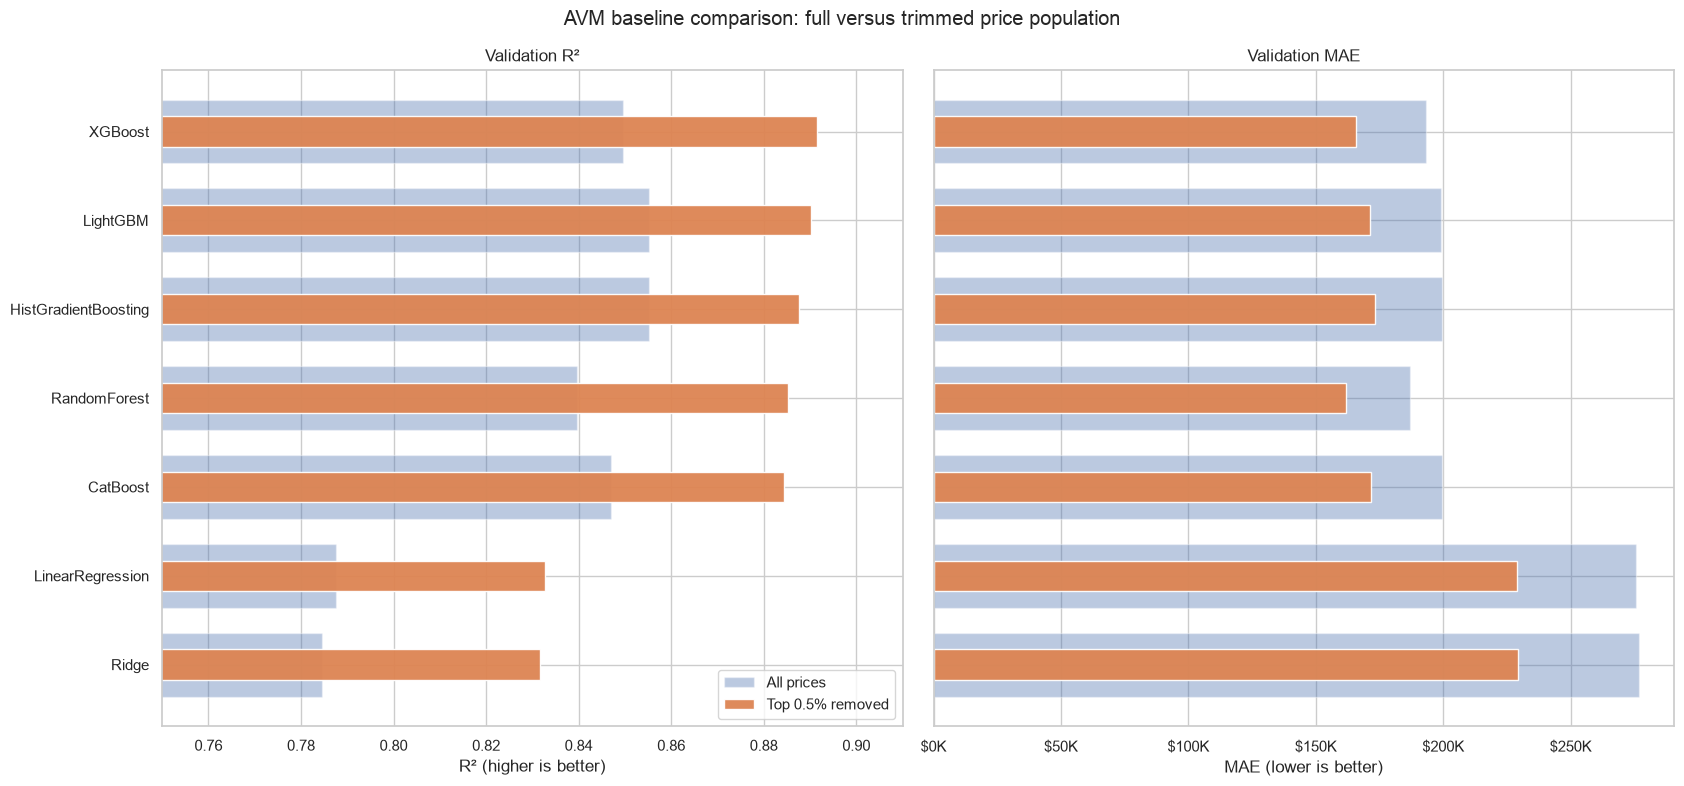

Saved data/week5_baseline_comparison_overlapping.png


In [37]:
BASELINE_COMPARISON_PLOT = Path("data/week5_baseline_comparison_overlapping.png")
models = baseline_comparison_table.index.tolist()
y_positions = np.arange(len(models))
all_color, trimmed_color = sns.color_palette("deep", 2)

fig, axes = plt.subplots(1, 2, figsize=(17, 8), sharey=True)

axes[0].barh(
    y_positions, baseline_comparison_table["r2_all_prices"],
    height=0.72, color=all_color, alpha=0.38, label="All prices",
)
axes[0].barh(
    y_positions, baseline_comparison_table["r2_trimmed_p995"],
    height=0.34, color=trimmed_color, alpha=0.95, label="Top 0.5% removed",
)
axes[0].set_xlim(0.75, 0.91)
axes[0].set_title("Validation R²")
axes[0].set_xlabel("R² (higher is better)")
axes[0].set_yticks(y_positions, labels=models)
axes[0].invert_yaxis()
axes[0].legend(loc="lower right")

axes[1].barh(
    y_positions, baseline_comparison_table["mae_all_prices"],
    height=0.72, color=all_color, alpha=0.38, label="All prices",
)
axes[1].barh(
    y_positions, baseline_comparison_table["mae_trimmed_p995"],
    height=0.34, color=trimmed_color, alpha=0.95, label="Top 0.5% removed",
)
axes[1].set_title("Validation MAE")
axes[1].set_xlabel("MAE (lower is better)")
axes[1].xaxis.set_major_formatter(FuncFormatter(lambda value, _: f"${value / 1000:.0f}K"))

fig.suptitle("AVM baseline comparison: full versus trimmed price population")
fig.tight_layout()
fig.savefig(BASELINE_COMPARISON_PLOT, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved {BASELINE_COMPARISON_PLOT}")

## Select by validation R² and evaluate May 2026 once

In [38]:
FINAL_TEST_FILE = Path("data/week5_selected_model_test_results.csv")
IMPORTANCE_FILE = Path("data/week5_selected_model_feature_importance.csv")

selected_population = best_configuration["population"]
selected_cutoff = POPULATIONS[selected_population]
final_test = test if selected_cutoff is None else test[test["ClosePrice"] <= selected_cutoff]
final_predictions = predict_artifact(best_artifact, final_test)
final_metrics = regression_metrics(final_test["ClosePrice"], final_predictions)

final_result = pd.DataFrame([{
    **{key: best_configuration[key] for key in ["population", "upper_cutoff", "feature_set", "model"]},
    "selection_metric": "validation_r2",
    "selected_validation_r2": best_validation_r2,
    "test_rows": len(final_test),
    "test_coverage_pct": len(final_test) / len(test) * 100,
    "test_r2": final_metrics["r2"],
    "test_mae": final_metrics["mae"],
    "test_rmse": final_metrics["rmse"],
}])
final_result.to_csv(FINAL_TEST_FILE, index=False)
final_result.T

,0
population,trimmed_p995
upper_cutoff,8200000.0
feature_set,avm_features
model,XGBoost
selection_metric,validation_r2
selected_validation_r2,0.891454
test_rows,11959
test_coverage_pct,99.550487
test_r2,0.886238
test_mae,172376.16262


## Selected-model feature importance or coefficients

In [39]:
selected_model = best_artifact["model"]
selected_spec = best_artifact["feature_spec"]

if best_artifact["kind"] == "catboost":
    importance = pd.DataFrame({
        "feature": feature_columns(selected_spec),
        "importance": selected_model.feature_importances_,
    })
    importance["importance_type"] = "catboost_feature_importance"
else:
    preprocessor = selected_model.named_steps["preprocessor"]
    estimator = selected_model.named_steps["model"]
    names = preprocessor.get_feature_names_out()
    if hasattr(estimator, "feature_importances_"):
        values = estimator.feature_importances_
        importance_type = "feature_importance"
    else:
        values = np.abs(np.ravel(estimator.coef_))
        importance_type = "absolute_coefficient"
    importance = pd.DataFrame({"feature": names, "importance": values})
    importance["importance_type"] = importance_type

importance = importance.sort_values("importance", ascending=False).reset_index(drop=True)
importance.to_csv(IMPORTANCE_FILE, index=False)
importance.head(25)

,feature,importance,importance_type
0,numeric__BathroomsTotalInteger,0.240644,feature_importance
1,numeric__LivingArea,0.137376,feature_importance
2,categorical__Levels,0.081997,feature_importance
3,categorical__CountyOrParish,0.073481,feature_importance
4,numeric__Longitude,0.064659,feature_importance
5,categorical__PostalCode,0.060804,feature_importance
6,numeric__Latitude,0.050767,feature_importance
7,categorical__MLSAreaMajor,0.037222,feature_importance
8,boolean__FireplaceYN,0.030982,feature_importance
9,numeric__BuildingAreaTotal,0.024296,feature_importance


## Modeling note

All reported models use only AVM-safe property, amenity, and location features. `ListPrice`, `OriginalListPrice`, and `DaysOnMarket` are absent from every model.

Baseline findings from this run:

- **Selected model:** trimmed-p99.5 XGBoost — validation R² **0.8915**, May test R² **0.8862**, and May coverage **99.55%**.
- **Best full-market model:** LightGBM — validation R² **0.8552** at 100% validation coverage.
- The nearly tied full-market HistGradientBoosting model also achieved validation R² **0.8552**.
- Removing the upper 0.5% improved every model's validation R², with the largest practical gains appearing in the nonlinear tree models and Linear Regression.

The selected XGBoost model is now a defensible AVM baseline for both on-market and off-market properties within the retained price population.

# Part 3: Residual diagnostics for the best two models

Compare the two highest-validation configurations—trimmed XGBoost and trimmed LightGBM—using the validation set only. A positive residual means the model **underpredicted** the sale price; a negative residual means it **overpredicted**.

In [40]:
RESIDUAL_FILE = Path("data/week5_top_two_validation_residuals.csv")
PRICE_BAND_FILE = Path("data/week5_residuals_by_price_band.csv")
LARGEST_GAPS_FILE = Path("data/week5_largest_residuals.csv")
RESIDUAL_PLOT_FILE = Path("data/week5_residual_diagnostics.png")
PRICE_BAND_PLOT_FILE = Path("data/week5_error_by_price_band.png")

top_two_configs = comparison_results.head(2)[
    ["population", "feature_set", "model", "validation_r2"]
].copy()
assert set(top_two_configs["model"]) == {"XGBoost", "LightGBM"}
top_two_configs

,population,feature_set,model,validation_r2
0,trimmed_p995,avm_features,XGBoost,0.891454
1,trimmed_p995,avm_features,LightGBM,0.890136


In [41]:
residual_frames = []
residual_artifacts = {}

for config in top_two_configs.itertuples(index=False):
    cutoff = POPULATIONS[config.population]
    diagnostic_train = train if cutoff is None else train[train["ClosePrice"] <= cutoff]
    diagnostic_validation = (
        validation if cutoff is None
        else validation[validation["ClosePrice"] <= cutoff]
    )
    spec = FEATURE_SETS[config.feature_set]
    artifact, _, predictions = fit_configuration(
        config.model, spec, diagnostic_train, diagnostic_validation
    )
    residual_artifacts[config.model] = artifact

    model_residuals = diagnostic_validation[[
        "ListingId", "CloseDate", "close_month", "City", "PostalCode",
        "LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "ClosePrice",
    ]].copy()
    model_residuals["model"] = config.model
    model_residuals["predicted_price"] = predictions
    model_residuals["residual"] = model_residuals["ClosePrice"] - predictions
    model_residuals["absolute_error"] = model_residuals["residual"].abs()
    model_residuals["absolute_percentage_error"] = (
        model_residuals["absolute_error"] / model_residuals["ClosePrice"] * 100
    )
    model_residuals["direction"] = np.where(
        model_residuals["residual"] >= 0, "underpredicted", "overpredicted"
    )
    residual_frames.append(model_residuals)

residual_results = pd.concat(residual_frames, ignore_index=True)
residual_results.to_csv(RESIDUAL_FILE, index=False)
print(f"Wrote {RESIDUAL_FILE} with {len(residual_results):,} model-row residuals")

Wrote data/week5_top_two_validation_residuals.csv with 63,108 model-row residuals


## Residual versus predicted and actual price

Dense regions are shown with hexagonal bins. The horizontal zero line represents a perfect prediction. Widening vertical spread at higher prices indicates heteroscedasticity.

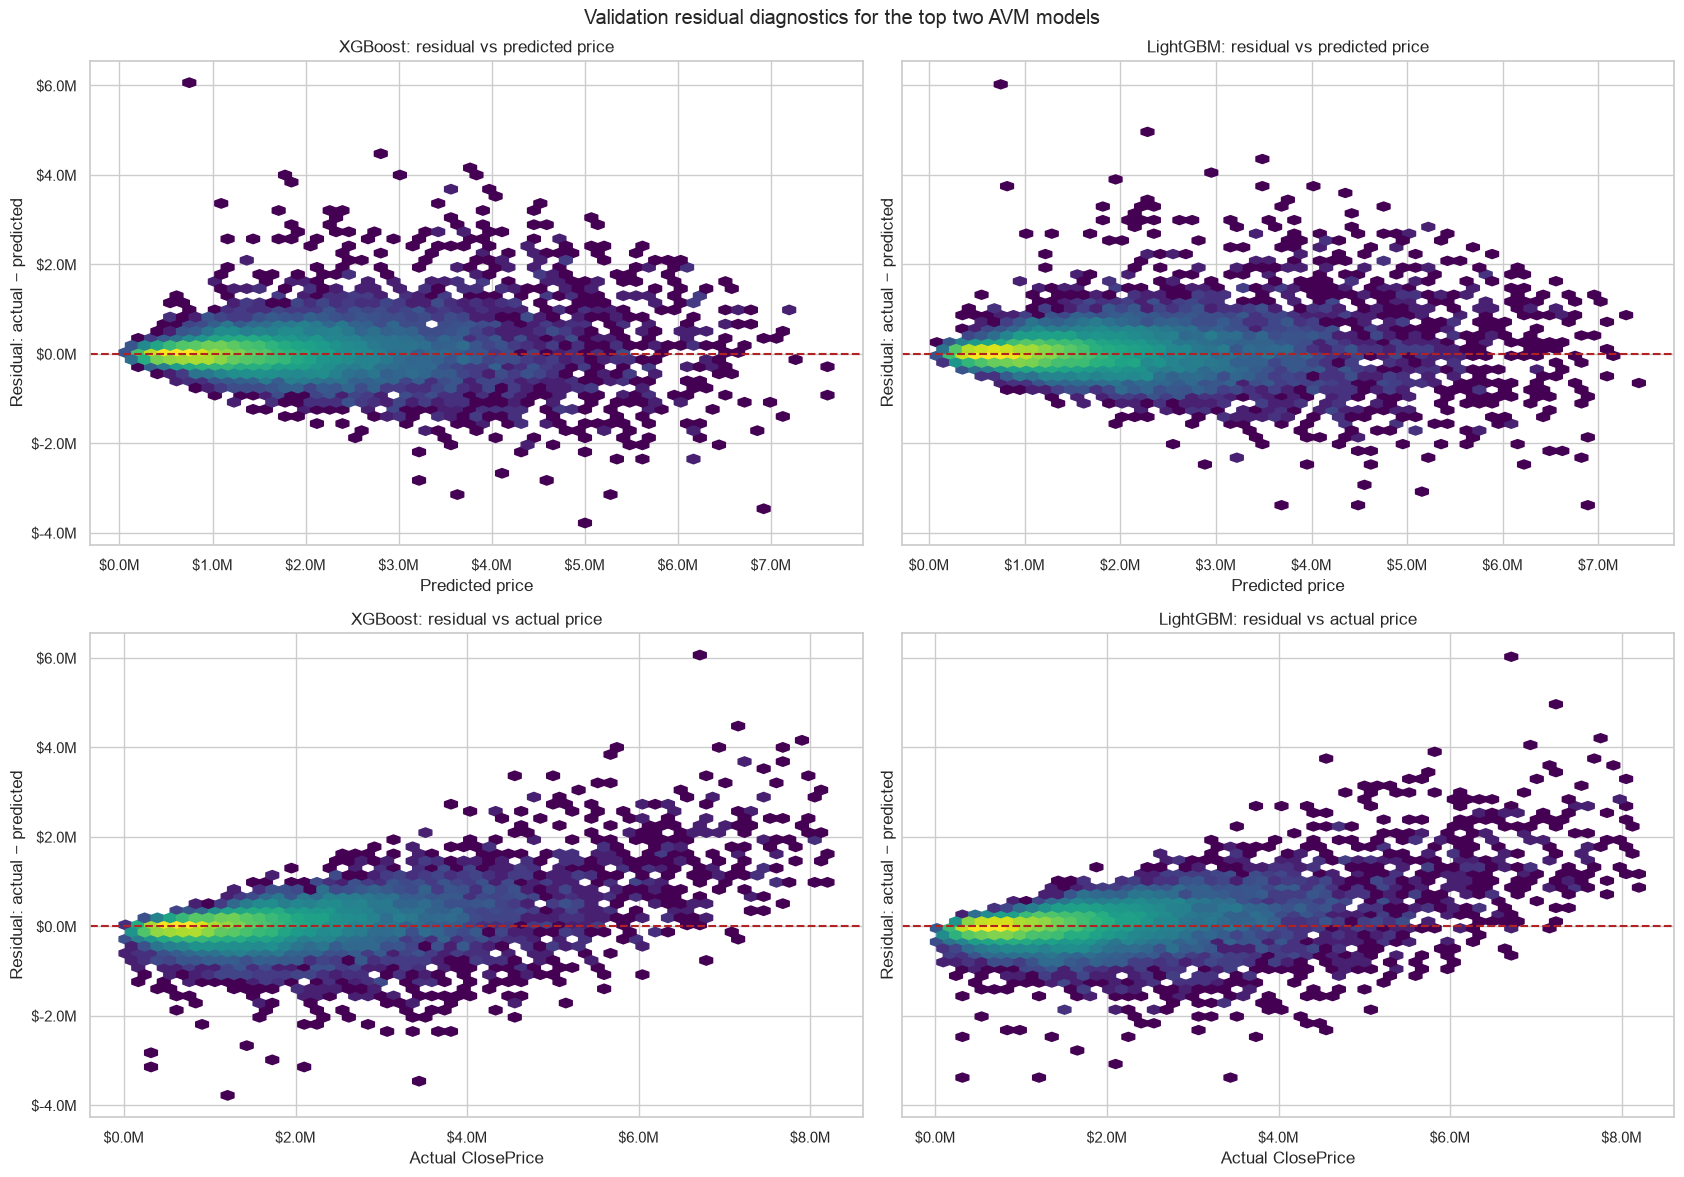

Saved data/week5_residual_diagnostics.png


In [42]:
model_order = top_two_configs["model"].tolist()
fig, axes = plt.subplots(2, 2, figsize=(17, 12), sharey=True)

for column_index, model_name in enumerate(model_order):
    model_data = residual_results[residual_results["model"] == model_name]
    axes[0, column_index].hexbin(
        model_data["predicted_price"], model_data["residual"],
        gridsize=55, bins="log", mincnt=1, cmap="viridis",
    )
    axes[0, column_index].axhline(0, color="firebrick", linestyle="--", linewidth=1.5)
    axes[0, column_index].set_title(f"{model_name}: residual vs predicted price")
    axes[0, column_index].set_xlabel("Predicted price")

    axes[1, column_index].hexbin(
        model_data["ClosePrice"], model_data["residual"],
        gridsize=55, bins="log", mincnt=1, cmap="viridis",
    )
    axes[1, column_index].axhline(0, color="firebrick", linestyle="--", linewidth=1.5)
    axes[1, column_index].set_title(f"{model_name}: residual vs actual price")
    axes[1, column_index].set_xlabel("Actual ClosePrice")

for ax in axes.flat:
    ax.set_ylabel("Residual: actual − predicted")
    ax.xaxis.set_major_formatter(FuncFormatter(millions))
    ax.yaxis.set_major_formatter(FuncFormatter(millions))

fig.suptitle("Validation residual diagnostics for the top two AVM models")
fig.tight_layout()
fig.savefig(RESIDUAL_PLOT_FILE, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved {RESIDUAL_PLOT_FILE}")

## Error by actual housing-price band

In [43]:
price_edges = [0, 250_000, 500_000, 750_000, 1_000_000, 1_500_000, 2_000_000, 3_000_000, 4_000_000, 6_000_000, 8_200_000]
price_labels = [
    "<$250K", "$250–500K", "$500–750K", "$750K–1M",
    "$1–1.5M", "$1.5–2M", "$2–3M", "$3–4M",
    "$4–6M", "$6–8.2M",
]
residual_results["price_band"] = pd.cut(
    residual_results["ClosePrice"], bins=price_edges, labels=price_labels, include_lowest=True
)

price_band_results = (
    residual_results.groupby(["model", "price_band"], observed=True)
    .agg(
        rows=("ClosePrice", "size"),
        mean_actual_price=("ClosePrice", "mean"),
        mae=("absolute_error", "mean"),
        median_absolute_error=("absolute_error", "median"),
        mean_residual=("residual", "mean"),
        median_absolute_percentage_error=("absolute_percentage_error", "median"),
    )
    .reset_index()
)
price_band_results["rmse"] = (
    residual_results.assign(squared_error=residual_results["residual"] ** 2)
    .groupby(["model", "price_band"], observed=True)["squared_error"]
    .mean().pow(0.5).to_numpy()
)
price_band_results.to_csv(PRICE_BAND_FILE, index=False)
price_band_results.round(2)

,model,price_band,rows,mean_actual_price,mae,median_absolute_error,mean_residual,median_absolute_percentage_error,rmse
0,LightGBM,<$250K,426,191165.47,130074.46,101503.39,-127427.15,50.63,185241.38
1,LightGBM,$250–500K,4215,406182.94,73351.84,46419.45,-44495.92,11.52,132469.45
2,LightGBM,$500–750K,7076,632089.86,78810.96,52434.81,-31426.90,8.27,123229.67
3,LightGBM,$750K–1M,6328,867278.21,98803.31,69842.78,-32373.54,8.09,149252.89
4,LightGBM,$1–1.5M,6221,1235518.52,156617.50,117335.47,359.31,9.57,223614.39
5,LightGBM,$1.5–2M,3190,1726664.18,239202.95,186711.56,31133.10,10.84,322568.41
6,LightGBM,$2–3M,2426,2430988.83,358949.42,289463.01,105908.21,12.03,475807.40
7,LightGBM,$3–4M,908,3461552.88,526402.82,426460.69,199772.90,12.26,687883.79
8,LightGBM,$4–6M,574,4810550.25,818259.87,658233.12,512345.75,14.17,1064122.35
9,LightGBM,$6–8.2M,190,6866954.63,1561581.79,1379391.38,1526556.64,20.84,1847504.03


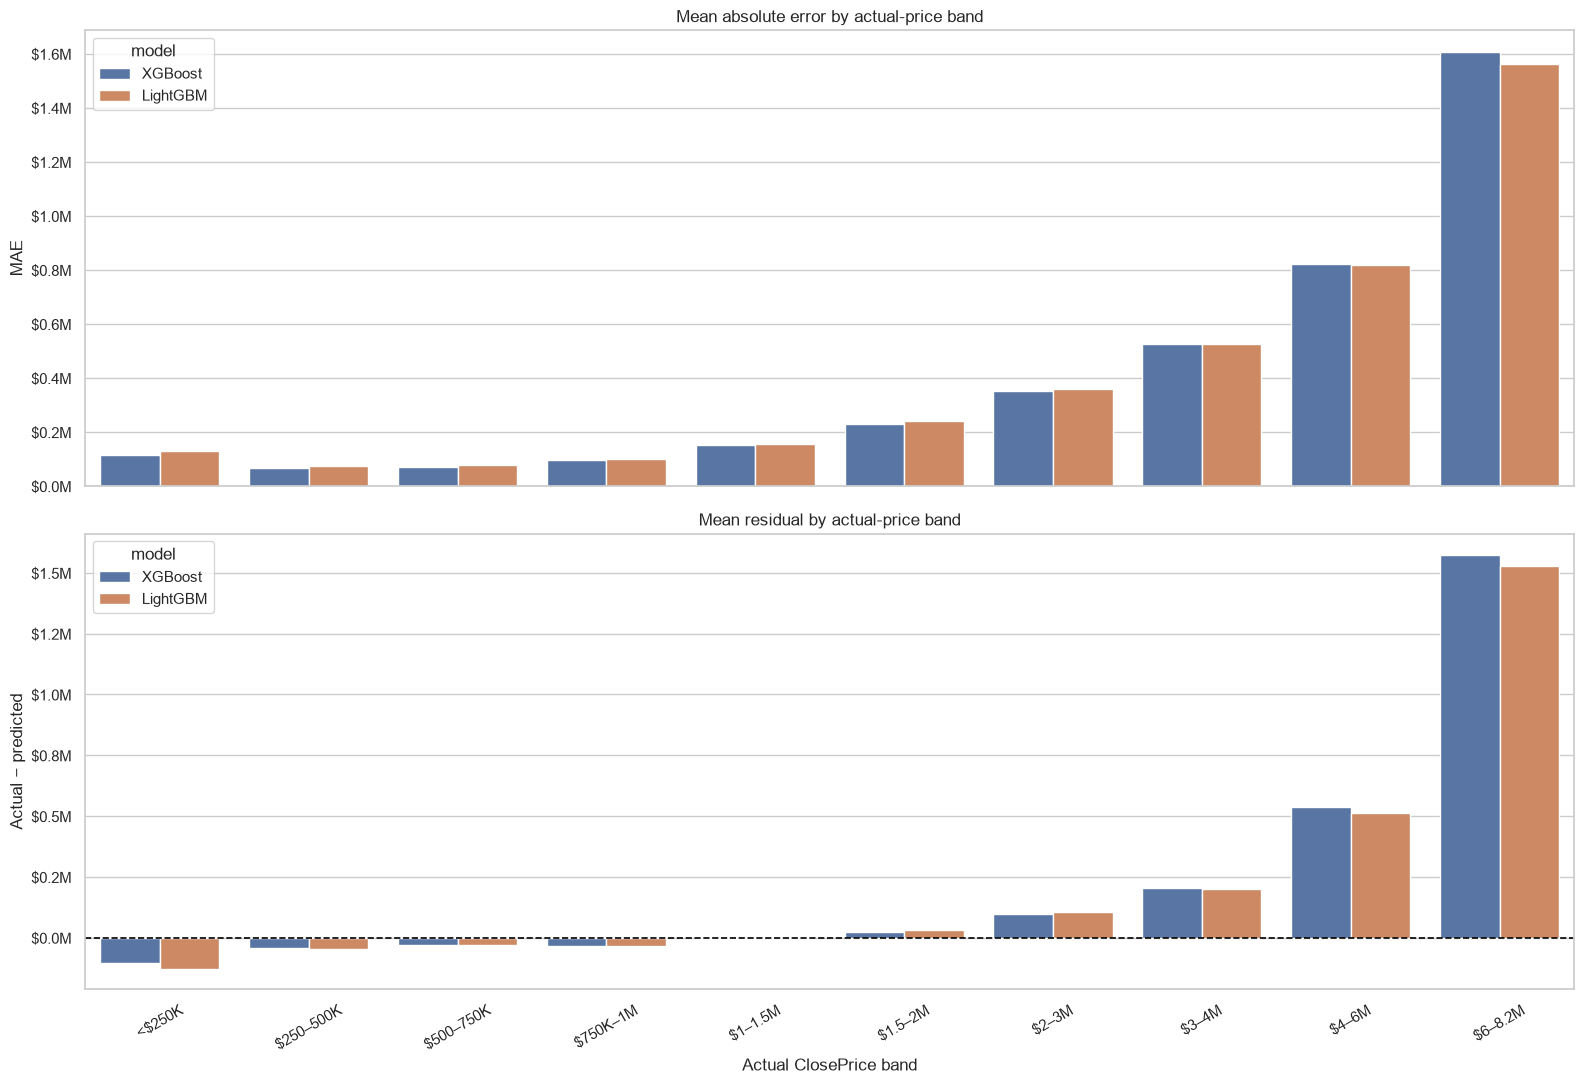

Saved data/week5_error_by_price_band.png


In [44]:
fig, axes = plt.subplots(2, 1, figsize=(16, 11), sharex=True)
sns.barplot(
    data=price_band_results, x="price_band", y="mae", hue="model",
    hue_order=model_order, ax=axes[0],
)
axes[0].set_title("Mean absolute error by actual-price band")
axes[0].set_ylabel("MAE")
axes[0].yaxis.set_major_formatter(FuncFormatter(millions))

sns.barplot(
    data=price_band_results, x="price_band", y="mean_residual", hue="model",
    hue_order=model_order, ax=axes[1],
)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1.2)
axes[1].set_title("Mean residual by actual-price band")
axes[1].set_ylabel("Actual − predicted")
axes[1].set_xlabel("Actual ClosePrice band")
axes[1].yaxis.set_major_formatter(FuncFormatter(millions))
axes[1].tick_params(axis="x", rotation=30)

fig.tight_layout()
fig.savefig(PRICE_BAND_PLOT_FILE, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved {PRICE_BAND_PLOT_FILE}")

## Residual findings

- Both models show increasing error variance as housing prices rise.
- The smallest dollar MAE occurs around **$250K–$500K**: approximately **$67.7K** for XGBoost and **$73.4K** for LightGBM.
- Homes below **$250K** are generally overpredicted. Mean residuals are approximately **−$103K** for XGBoost and **−$127K** for LightGBM.
- Homes above roughly **$1.5M** are increasingly underpredicted. In the **$6M–$8.2M** band, MAE reaches approximately **$1.61M** for XGBoost and **$1.56M** for LightGBM, with average underprediction around **$1.58M** and **$1.53M**, respectively.
- The largest shared miss is a Murrieta sale at **$6.75M** that both models predicted near **$0.7M**, producing an error of roughly **$6.0M**. This transaction should be inspected for unusual property attributes or data-quality issues.

These diagnostics use validation rows only; no additional May test analysis was performed.